In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import netCDF4
import os
import xagg

In [2]:
scratch = '/glade/derecho/scratch/dcalhoun'

In [3]:
gdf = gpd.read_file(scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp')

In [4]:
gdf.columns

Index(['GISJOIN', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ',
       'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP',
       'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'Shape_Leng', 'Shape_Area', 'ORIG_FID', 'geometry'],
      dtype='str')

In [ ]:
ds = xr.open_mfdataset([scratch + '/ecmwf/ifs/fc/0.125/2t/0000/24/2020/08/ifs_fc_2t_0000_24_20200821.nc', scratch + '/ecmwf/ifs/fc/0.125/2t/1200/24/2020/08/ifs_fc_2t_1200_24_20200821.nc'])

In [28]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 2, latitude: 201, longitude: 469)
Coordinates:
  * time       (time) datetime64[ns] 16B 2020-08-22 2020-08-22T12:00:00
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
Data variables:
    t2m        (time, latitude, longitude) float64 2MB dask.array<chunksize=(1, 201, 469), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2025-04-09 19:21:17 GMT by grib_to_netcdf-2.34.0: grib_to_n...

In [6]:
weightmap = xagg.pixel_overlaps(ds, gdf, silent=True)

In [19]:
aggregated = xagg.aggregate(ds, weightmap, silent=True)

In [22]:
ds_agg = aggregated.to_dataframe().dropna(subset=['t2m']).reset_index().drop(columns=['poly_idx']).rename(columns={'time': 'valid_time'})

In [9]:
ds_agg.columns

Index(['valid_time', 'GISJOIN', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID',
       'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP',
       'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'Shape_Leng', 'Shape_Area', 'ORIG_FID', 't2m'],
      dtype='str')

In [23]:
ds_agg['lead'] = 24

In [24]:
ds_agg['init_time'] = pd.to_datetime(ds_agg['valid_time']) - pd.to_timedelta(ds_agg['lead'], unit='h')

In [25]:
ds_agg

,valid_time,GISJOIN,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,...,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,ORIG_FID,t2m,lead,init_time
0,2020-08-22 00:00:00,G0100010,01,001,00161526,01001,0500000US01001,Autauga,Autauga County,06,...,1.539631e+09,2.567754e+07,+32.5322367,-086.6464395,210512.579904,1.565309e+09,772,297.717385,24,2020-08-21 00:00:00
1,2020-08-22 12:00:00,G0100010,01,001,00161526,01001,0500000US01001,Autauga,Autauga County,06,...,1.539631e+09,2.567754e+07,+32.5322367,-086.6464395,210512.579904,1.565309e+09,772,294.635359,24,2020-08-21 12:00:00
2,2020-08-22 00:00:00,G0100030,01,003,00161527,01003,0500000US01003,Baldwin,Baldwin County,06,...,4.117725e+09,1.132887e+09,+30.6592183,-087.7460666,672315.878198,4.254346e+09,297,299.665138,24,2020-08-21 00:00:00
3,2020-08-22 12:00:00,G0100030,01,003,00161527,01003,0500000US01003,Baldwin,Baldwin County,06,...,4.117725e+09,1.132887e+09,+30.6592183,-087.7460666,672315.878198,4.254346e+09,297,295.545118,24,2020-08-21 12:00:00
4,2020-08-22 00:00:00,G0100050,01,005,00161528,01005,0500000US01005,Barbour,Barbour County,06,...,2.292160e+09,5.052321e+07,+31.8702531,-085.4051035,272036.648100,2.342684e+09,833,299.922064,24,2020-08-21 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6213,2020-08-22 12:00:00,G5600410,56,041,01605084,56041,0500000US56041,Uinta,Uinta County,06,...,5.391632e+09,1.662582e+07,+41.2847255,-110.5589468,296097.366183,5.408258e+09,1032,286.521437,24,2020-08-21 12:00:00
6214,2020-08-22 00:00:00,G5600430,56,043,01605085,56043,0500000US56043,Washakie,Washakie County,06,...,5.798152e+09,1.041589e+07,+43.8788305,-107.6690520,381914.083299,5.808569e+09,1224,303.896231,24,2020-08-21 00:00:00
6215,2020-08-22 12:00:00,G5600430,56,043,01605085,56043,0500000US56043,Washakie,Washakie County,06,...,5.798152e+09,1.041589e+07,+43.8788305,-107.6690520,381914.083299,5.808569e+09,1224,290.877364,24,2020-08-21 12:00:00
6216,2020-08-22 00:00:00,G5600450,56,045,01605086,56045,0500000US56045,Weston,Weston County,06,...,6.210804e+09,5.225499e+06,+43.8462133,-104.5700202,315656.514130,6.216030e+09,1797,305.369638,24,2020-08-21 00:00:00


In [41]:
ds_fc = ds_agg[['GEOID', 'valid_time', 'init_time', 'lead', 't2m']]

In [42]:
ds_fc.groupby('init_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
init_time,,,,,,,,
2020-08-21 00:00:00,3109.0,299.864516,4.227715,286.674303,296.739751,299.82875,302.895949,314.707180
2020-08-21 12:00:00,3109.0,293.189746,2.779538,278.377451,291.865343,293.19134,294.697683,303.203374


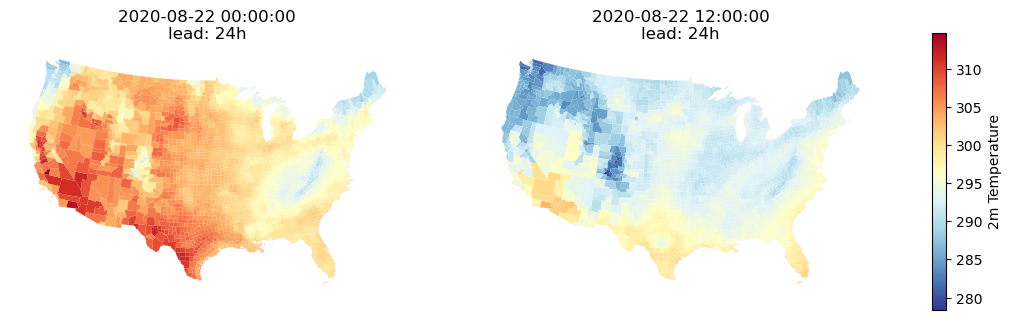

In [43]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmin, vmax = ds_fc['t2m'].min(), ds_fc['t2m'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdYlBu_r'

for ax, (valid_time, sub) in zip(axes, ds_fc.groupby('valid_time')):
    gdf_plot = gdf.merge(sub[['GEOID', 't2m']], on='GEOID', how='inner')
    gdf_plot.plot(ax=ax, column='t2m', cmap=cmap, norm=norm)
    lead_val = sub['lead'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.6, label='2m Temperature')
plt.show()